In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.shape

(200, 5)

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [7]:
df = pd.get_dummies(df, columns = ['Genre'], drop_first = True, dtype  = int)

In [8]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [9]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)','Genre_Male']]

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Inertia values:  [799.9999999999999, 597.9472937932279, 494.8037500130457, 395.3920903479797, 351.74320617119116, 277.38974019851906, 251.15484911190174, 211.98576294959307, 185.72807688711416]


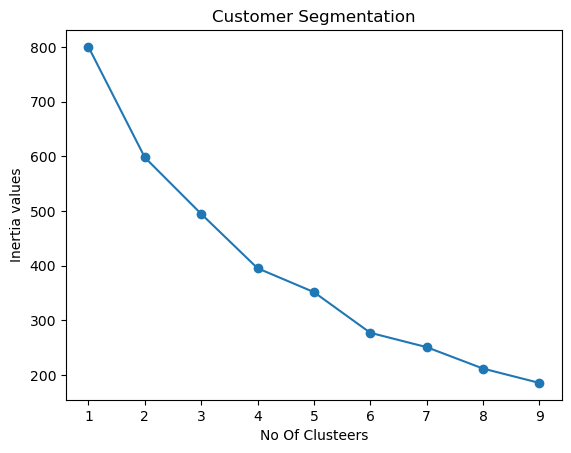

In [12]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 10): 
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
print('Inertia values: ', wcss)

import matplotlib.pyplot as plt
plt.plot(range(1,10), wcss, marker = 'o')
plt.xlabel('No Of Clusteers')
plt.ylabel('Inertia values')
plt.title('Customer Segmentation')
plt.show()

In [13]:
km = KMeans(n_clusters = 4, random_state = 42)
km.fit(X_scaled)
labels = km.labels_
df['km_clusters'] = labels
print(df['km_clusters'].value_counts())

km_clusters
3    64
0    60
2    42
1    34
Name: count, dtype: int64


In [14]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,km_clusters
0,1,19,15,39,1,2
1,2,21,15,81,1,2
2,3,20,16,6,0,3
3,4,23,16,77,0,3
4,5,31,17,40,0,3


In [15]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
X_c1 = tsne.fit_transform(X_scaled)
print('Compressed Shape: ', X_c1.shape)

Compressed Shape:  (200, 2)


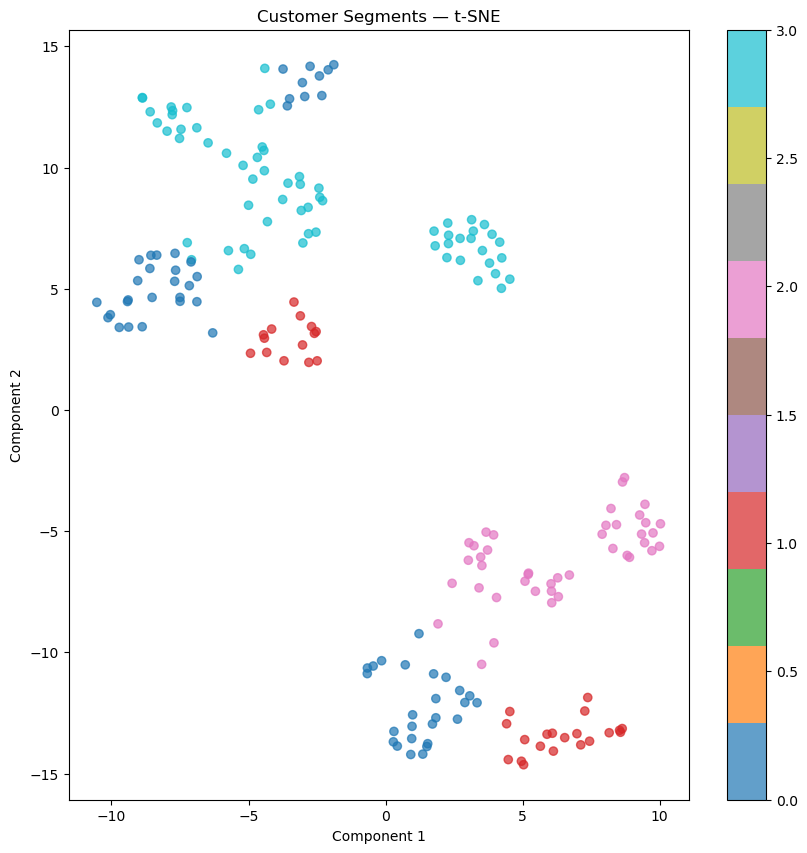

In [16]:
plt.figure(figsize = (10,10))
scat = plt.scatter(X_c1[:,0], X_c1[:,1], c=labels, cmap = 'tab10', alpha = 0.7)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Customer Segments — t-SNE')
plt.colorbar(scat)
plt.show()

In [17]:
df.groupby('km_clusters')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
km_clusters,,,
0,54.700000,46.900000,39.933333
1,41.264706,88.500000,16.764706
2,28.690476,60.904762,70.238095
3,29.375000,58.296875,64.437500


In [19]:
print('Cluster 0 -> Older Low Spenders')
print('Cluster 1 -> High Earners Low Spenders')
print('Cluster 2 -> Young High Spenders')
print('Cluster 3 -> Young Moderate Spenders')

Cluster 0 -> Older Low Spenders
Cluster 1 -> High Earners Low Spenders
Cluster 2 -> Young High Spenders
Cluster 3 -> Young Moderate Spenders
